<a href="https://colab.research.google.com/github/alexklupsch/wur_deep_learning/blob/main/single_label_resnet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Single Label Image Classification -- UCM airborne images -- Resnet18 Fine-Tuning

This notebook shows an easy implementation of the fine-tuning of a resnet18 model to classify the 21 classes of the UCM dataset showing airborne Land Use categories.
It follows the implementation of a medium article (https://medium.com/@imabhi1216/fine-tuning-a-pre-trained-resnet-18-model-for-image-classification-on-custom-dataset-with-pytorch-02df12e83c2c)
and adds wandb (weights and biases to the project).


## 1. Data Loading and Preparation

In [2]:
import os
import zipfile

## loading the data and directory handling
! git clone https://git.wur.nl/lobry001/ucmdata.git
os.chdir('ucmdata')

with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
  zip_ref.extractall('UCMImages')

!mv UCMImages/UCMerced_LandUse/Images .
!rm -rf UCMImages README.md UCMerced_LandUse.zip
!ls

UCM_images_path = "Images/"
Multilabels_path = "LandUse_Multilabeled.txt"

Cloning into 'ucmdata'...
remote: Enumerating objects: 8, done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 8 (from 1)
Receiving objects: 100% (8/8), 316.99 MiB | 13.43 MiB/s, done.
Images	LandUse_Multilabeled.txt


In [13]:
## Accessing the images
dir = "/content/ucmdata/Images"
image_dict = {} # dict for key:class, value: [image_paths]
class_index_dict = {} # dict for key:class_num, value: class_name

for class_num, class_name in enumerate(os.listdir(dir)):
  class_index_dict[class_num] = class_name
  class_dir = os.path.join(dir, class_name)

  if os.path.isdir(class_dir): # sort out *.txt-file
    image_paths = [os.path.join(class_dir, image) for image in os.listdir(class_dir)]
    image_dict[class_num] = image_paths


In [14]:
import random

def split_train_test(image_dict, val_ratio, test_ratio):

  random.seed(42) # to ensure the same test set for different models
  train_dataset = []
  val_dataset = []
  test_dataset = []

  for label, image_paths in image_dict.items():

    sample_length = len(image_paths)

    ## split off the test_dataset with the fixed random seed first to keep test set consistent
    random.shuffle(image_paths)

    test_split = int(sample_length * test_ratio)
    test_dataset.extend([(image, label) for image in image_paths[:test_split]])
    image_paths = image_paths[test_split:]

    ## reshuffle to mix up training and validation data for different runs
    random.seed()
    random.shuffle(image_paths)

    val_split = int(sample_length * val_ratio)

    val_dataset.extend([(image, label) for image in image_paths[:val_split]])
    train_dataset.extend([(image, label) for image in image_paths[val_split:]])

  return train_dataset, val_dataset, test_dataset

train_dataset,val_dataset, test_dataset = split_train_test(image_dict, val_ratio = 0.15, test_ratio=0.15)

In [16]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_first_per_class(data, index_to_class, cols=5, figsize=(15, 3)):
    """
    Plots the first image for each class.

    Parameters:
    - data: list of (image_path, label)
    - index_to_class: dict {label_num: class_name}
    - cols: number of columns in the grid
    - figsize: base figure size (width, height per row)
    """

    # Collect first image per label
    first_image_per_label = {}
    for image_path, label in data:
        if label not in first_image_per_label:
            first_image_per_label[label] = image_path

    labels = sorted(first_image_per_label.keys())
    num_classes = len(labels)
    rows = (num_classes + cols - 1) // cols

    plt.figure(figsize=(figsize[0], figsize[1] * rows))

    for i, label in enumerate(labels):
        image_path = first_image_per_label[label]
        class_name = index_to_class.get(label, "unknown")

        with Image.open(image_path) as img:
            img = img.convert("RGB")

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"{label}: {class_name}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

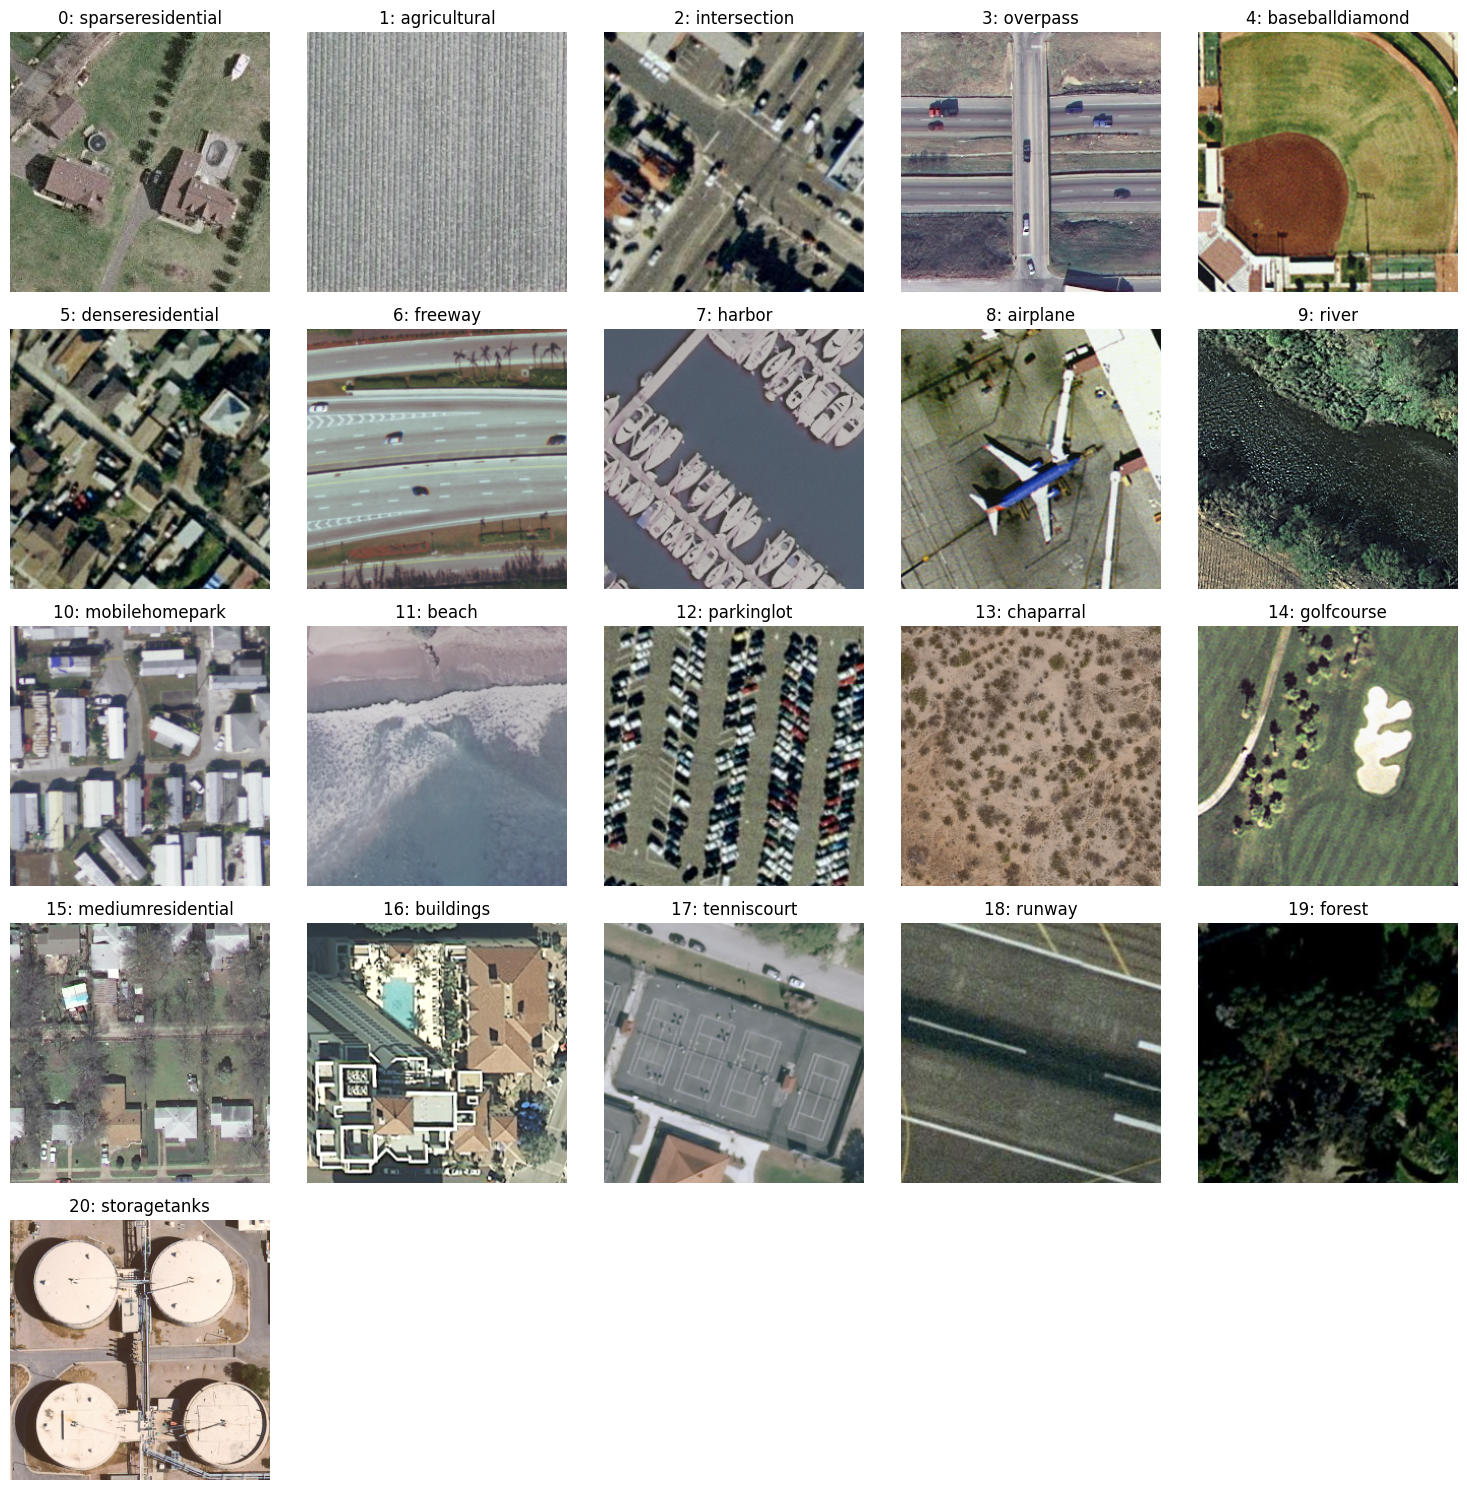

In [18]:
plot_first_per_class(train_dataset, class_index_dict)